# Option Pricing Models: From Binomial Trees to Stochastic Volatility

This notebook prices the same European call option five ways and checks each method against the others:

1. **Binomial tree** (Cox-Ross-Rubinstein)
2. **Black-Scholes** closed form
3. **Monte Carlo** under risk-neutral geometric Brownian motion (GBM)
4. **Heston** stochastic volatility, semi-analytic (characteristic function)
5. **Heston** Monte Carlo, used to validate the semi-analytic price

It also compares Euler and exact GBM discretization, and shows how Heston produces an implied-volatility skew that Black-Scholes cannot.

**Design choices worth noting**
- *Validation over assertion:* every numerical method is checked against a closed form or an independent method, with the gap reported.
- *Common random numbers:* when comparing methods or parameter values, the same random draws are reused, so differences reflect the model rather than simulation noise.
- *Standard errors:* every Monte Carlo price is reported with its standard error and 95% confidence interval.

**Data:** daily adjusted prices from Yahoo Finance via `yfinance`. The ticker and sample period are set in the configuration cell and can be changed.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import brentq

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

# ---------------- configuration ----------------
TICKER     = 'MSFT'          # underlying asset
START      = '2021-01-01'    # estimation sample start
END        = '2025-12-31'    # estimation sample end
R          = 0.04            # annual risk-free rate (continuous), approx. 1-year Treasury yield
TRADING_DAYS = 252
SEED       = 2026            # one seed for the whole notebook, for reproducibility

## 2. Data and parameter estimation

Log returns are used to estimate volatility, because under GBM log returns are normally distributed with variance $\sigma^2 \Delta t$. The GBM drift is $\mu = \bar r_{\log} + \tfrac{1}{2}\sigma^2$, the Itô correction that converts the mean log return into the mean simple return.

In [2]:
import yfinance as yf

px = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)['Close'].squeeze().dropna()
ret_simple = px.pct_change().dropna()
ret_log    = np.log(px / px.shift(1)).dropna()

sigma = ret_log.std() * np.sqrt(TRADING_DAYS)          # annualized volatility
mu    = ret_log.mean() * TRADING_DAYS + 0.5 * sigma**2  # GBM drift (Ito-corrected)
S0    = float(px.iloc[-1])                              # latest price as spot

print(f'{TICKER}: {len(px)} trading days, {px.index[0].date()} to {px.index[-1].date()}')
print(f'Spot price S0          : ${S0:,.2f}')
print(f'Annualized volatility  : {sigma:.2%}')
print(f'Annualized GBM drift mu: {mu:.2%}')
print(f'Mean simple vs log daily return: {ret_simple.mean():.5f} vs {ret_log.mean():.5f}')

MSFT: 1254 trading days, 2021-01-04 to 2025-12-30
Spot price S0          : $484.41
Annualized volatility  : 25.68%
Annualized GBM drift mu: 20.34%
Mean simple vs log daily return: 0.00081 vs 0.00068


## 3. GBM simulation: Euler vs exact discretization

- **Euler:** $S_{t+\Delta t} = S_t\,(1 + \mu\Delta t + \sigma\sqrt{\Delta t}\,Z)$, a first-order approximation of the SDE.
- **Exact:** $S_{t+\Delta t} = S_t \exp\big[(\mu - \tfrac12\sigma^2)\Delta t + \sigma\sqrt{\Delta t}\,Z\big]$, the closed-form solution, correct for any step size.

Both methods use **the same random draws $Z$** within each step size, so any difference between them is discretization error, not noise. The exact terminal distribution is known (lognormal), so each case is also compared with the true mean, median and percentiles.

In [3]:
T_SIM, N_PATHS = 1.0, 20_000

def simulate_gbm(S0, mu, sigma, T, n_steps, Z, method):
    # Z has shape (n_steps, n_paths); returns price paths of shape (n_steps+1, n_paths)
    dt = T / n_steps
    S = np.empty((n_steps + 1, Z.shape[1])); S[0] = S0
    for t in range(n_steps):
        if method == 'euler':
            S[t+1] = np.maximum(S[t] * (1 + mu*dt + sigma*np.sqrt(dt)*Z[t]), 0.0)
        else:
            S[t+1] = S[t] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t])
    return S

rng = np.random.default_rng(SEED)
paths = {}
for label, n_steps in [('Weekly', 52), ('Monthly', 12)]:
    Z = rng.standard_normal((n_steps, N_PATHS))   # shared by Euler and exact
    for method in ['euler', 'exact']:
        paths[f'{label} / {method.capitalize()}'] = simulate_gbm(S0, mu, sigma, T_SIM, n_steps, Z, method)

# true lognormal terminal distribution under GBM
m_log, s_log = np.log(S0) + (mu - 0.5*sigma**2)*T_SIM, sigma*np.sqrt(T_SIM)
truth = {'Mean': S0*np.exp(mu*T_SIM), 'Median': np.exp(m_log),
         'Std': S0*np.exp(mu*T_SIM)*np.sqrt(np.exp(sigma**2*T_SIM) - 1),
         'P5': np.exp(m_log + s_log*norm.ppf(0.05)), 'P95': np.exp(m_log + s_log*norm.ppf(0.95))}

rows = []
for name, S in paths.items():
    ST = S[-1]
    rows.append({'Case': name, 'Mean': ST.mean(), 'Median': np.median(ST), 'Std': ST.std(),
                 'P5': np.percentile(ST, 5), 'P95': np.percentile(ST, 95)})
rows.append({'Case': 'True lognormal', **truth})
gbm_table = pd.DataFrame(rows).set_index('Case')
print('Table 1: Terminal price distribution after one year')
display(gbm_table.round(2))

print('\nTable 2: Error vs the true distribution (% of true value)')
display(((gbm_table.iloc[:-1] / gbm_table.loc['True lognormal'] - 1) * 100).round(2))

# paired comparison: same random draws, so this gap is pure discretization error
print('\nTable 3: Euler minus exact, same random draws (% of exact)')
pair = pd.DataFrame({lab: (gbm_table.loc[f'{lab} / Euler'] / gbm_table.loc[f'{lab} / Exact'] - 1) * 100
                     for lab in ['Weekly', 'Monthly']}).T
display(pair.round(3))

Table 1: Terminal price distribution after one year


,Mean,Median,Std,P5,P95
Case,,,,,
Weekly / Euler,593.28,574.23,154.49,375.29,872.91
Weekly / Exact,593.52,574.05,155.22,375.19,874.44
Monthly / Euler,593.72,576.16,154.23,375.44,871.20
Monthly / Exact,594.77,575.00,157.50,374.88,880.16
True lognormal,593.67,574.42,154.98,376.54,876.30



Table 2: Error vs the true distribution (% of true value)


,Mean,Median,Std,P5,P95
Case,,,,,
Weekly / Euler,-0.07,-0.03,-0.31,-0.33,-0.39
Weekly / Exact,-0.03,-0.06,0.15,-0.36,-0.21
Monthly / Euler,0.01,0.30,-0.48,-0.29,-0.58
Monthly / Exact,0.18,0.10,1.62,-0.44,0.44



Table 3: Euler minus exact, same random draws (% of exact)


,Mean,Median,Std,P5,P95
Weekly,-0.041,0.031,-0.465,0.028,-0.175
Monthly,-0.176,0.201,-2.073,0.148,-1.018


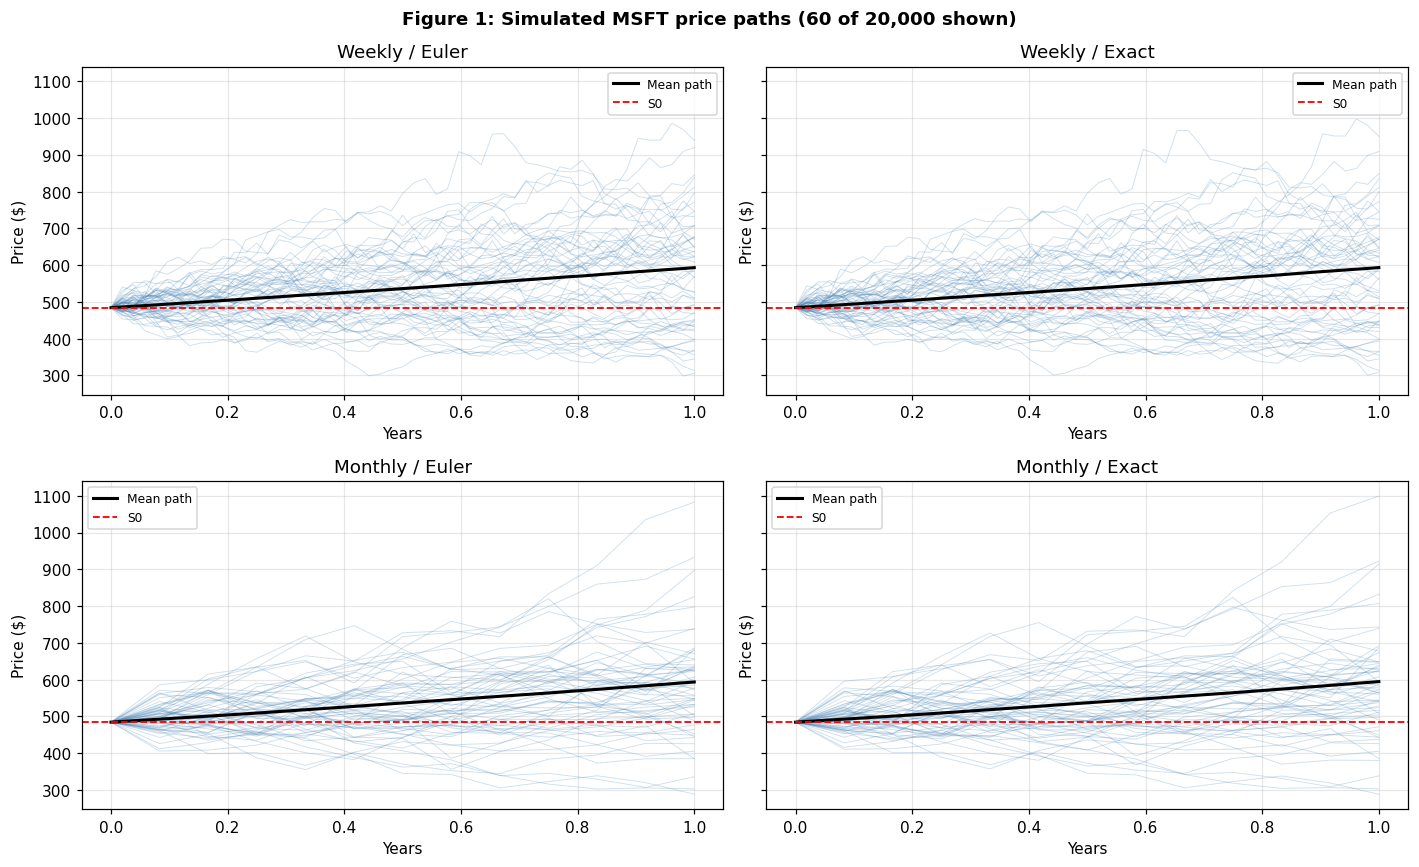

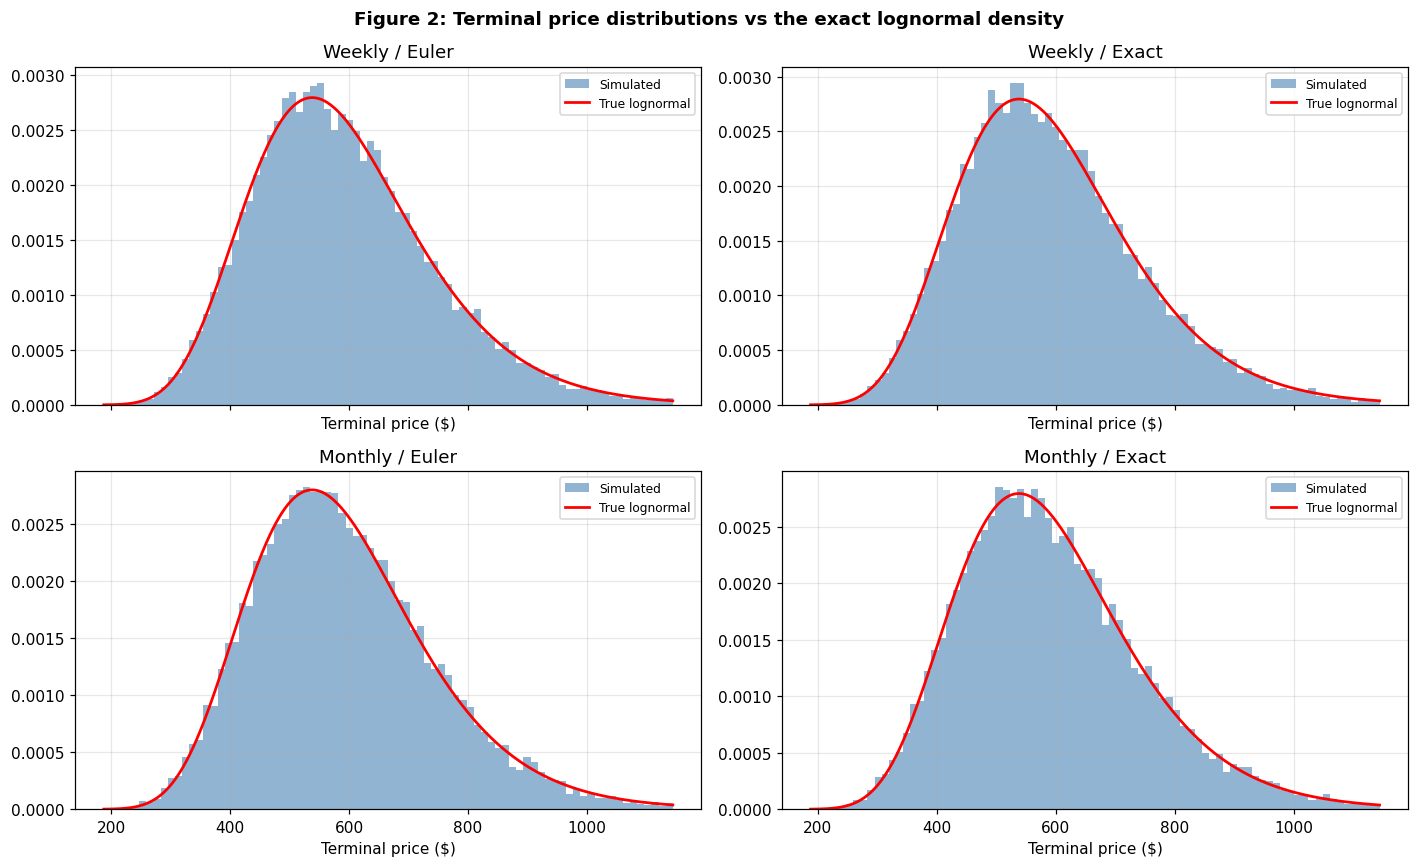

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for ax, (name, S) in zip(axes.flat, paths.items()):
    t = np.linspace(0, T_SIM, S.shape[0])
    ax.plot(t, S[:, :60], lw=0.6, alpha=0.25, color='steelblue')
    ax.plot(t, S.mean(axis=1), color='black', lw=2, label='Mean path')
    ax.axhline(S0, color='red', ls='--', lw=1.2, label='S0')
    ax.set(title=name, xlabel='Years', ylabel='Price ($)'); ax.legend(fontsize=8)
fig.suptitle(f'Figure 1: Simulated {TICKER} price paths (60 of {N_PATHS:,} shown)', fontweight='bold')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
grid = np.linspace(gbm_table['P5'].min()*0.5, gbm_table['P95'].max()*1.3, 400)
true_pdf = norm.pdf(np.log(grid), m_log, s_log) / grid
for ax, (name, S) in zip(axes.flat, paths.items()):
    ax.hist(S[-1], bins=80, range=(grid[0], grid[-1]), density=True, alpha=0.6, color='steelblue', label='Simulated')
    ax.plot(grid, true_pdf, color='red', lw=1.8, label='True lognormal')
    ax.set(title=name, xlabel='Terminal price ($)'); ax.legend(fontsize=8)
fig.suptitle('Figure 2: Terminal price distributions vs the exact lognormal density', fontweight='bold')
plt.tight_layout(); plt.show()

**Reading the results.** Table 2 compares each case with the true lognormal distribution, and Table 3 isolates the discretization error by comparing Euler and exact on the *same* random draws.

- **Exact** matches the true distribution at both step sizes up to simulation noise, because it samples the closed-form solution directly. Its step size only changes how many intermediate points are recorded, not the accuracy of the terminal price.
- **Euler** treats each step's return as normal rather than lognormal. Its error grows with the step size and with volatility, and it mainly shows up in the tails (standard deviation and P95), since compounding many small normal steps approximates the lognormal shape better than a few large ones. For a moderate-volatility stock the error is small at weekly steps; it becomes material for large steps or high volatility, and Euler can even produce negative prices, which is why the code floors them at zero.

**Recommendation:** use the exact scheme whenever a closed form exists; use Euler, with small steps, only when it doesn't, as for the Heston variance process below.

**Limitations of GBM:** (1) volatility is constant, while real volatility clusters; (2) log returns are normal, so fat tails are missing; (3) paths are continuous, so jumps on earnings or news are missing; (4) drift estimated from a few years of data is very noisy, which is why option pricing below uses the risk-free rate instead.

## 4. Binomial tree (Cox-Ross-Rubinstein)

The up and down factors are calibrated to the estimated volatility, $u = e^{\sigma\sqrt{\Delta t}}$, $d = 1/u$, so the tree converges to Black-Scholes as the number of steps grows. The risk-neutral probability is $p = (e^{r\Delta t} - d)/(u - d)$, which requires $d < e^{r\Delta t} < u$.

The option is at the money with one year to maturity. Prices are scaled so that $S_0 = K = 100$, which makes results easy to read; option prices scale proportionally with $S_0$.

In [5]:
S, K, T = 100.0, 100.0, 1.0

def crr_price(S, K, T, r, sigma, n, kind='call'):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    assert 0 < p < 1, 'no-arbitrage condition violated'
    ST = S * u**np.arange(n + 1) * d**np.arange(n, -1, -1)
    V = np.maximum(ST - K, 0) if kind == 'call' else np.maximum(K - ST, 0)
    for _ in range(n):
        V = np.exp(-r * dt) * (p * V[1:] + (1 - p) * V[:-1])
    return float(V[0])

def bs_price(S, K, T, r, sigma, kind='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

N_TREE = 500
call_tree, put_tree = crr_price(S, K, T, R, sigma, N_TREE, 'call'), crr_price(S, K, T, R, sigma, N_TREE, 'put')
dt = T / N_TREE; u = np.exp(sigma*np.sqrt(dt))
print(f'u = {u:.5f}, d = {1/u:.5f}, p = {(np.exp(R*dt) - 1/u)/(u - 1/u):.4f}  (n = {N_TREE})')
print(f'European call: ${call_tree:.4f}')
print(f'European put : ${put_tree:.4f}')

# put-call parity: C - P = S - K e^{-rT}
lhs, rhs = call_tree - put_tree, S - K * np.exp(-R * T)
print(f'\nPut-call parity: C - P = {lhs:.6f}, S - Ke^(-rT) = {rhs:.6f}, gap = {abs(lhs - rhs):.2e}')

u = 1.01155, d = 0.98858, p = 0.5006  (n = 500)
European call: $12.0911
European put : $8.1701

Put-call parity: C - P = 3.921056, S - Ke^(-rT) = 3.921056, gap = 2.64e-12


**Put-call parity holds to machine precision.** This is expected rather than a coincidence: in any arbitrage-free binomial tree, a call minus a put pays $S_T - K$ in every terminal state, and the tree prices that payoff at exactly $S_0 - Ke^{-rT}$. Parity is therefore a useful check on the implementation; a visible gap would signal a bug.

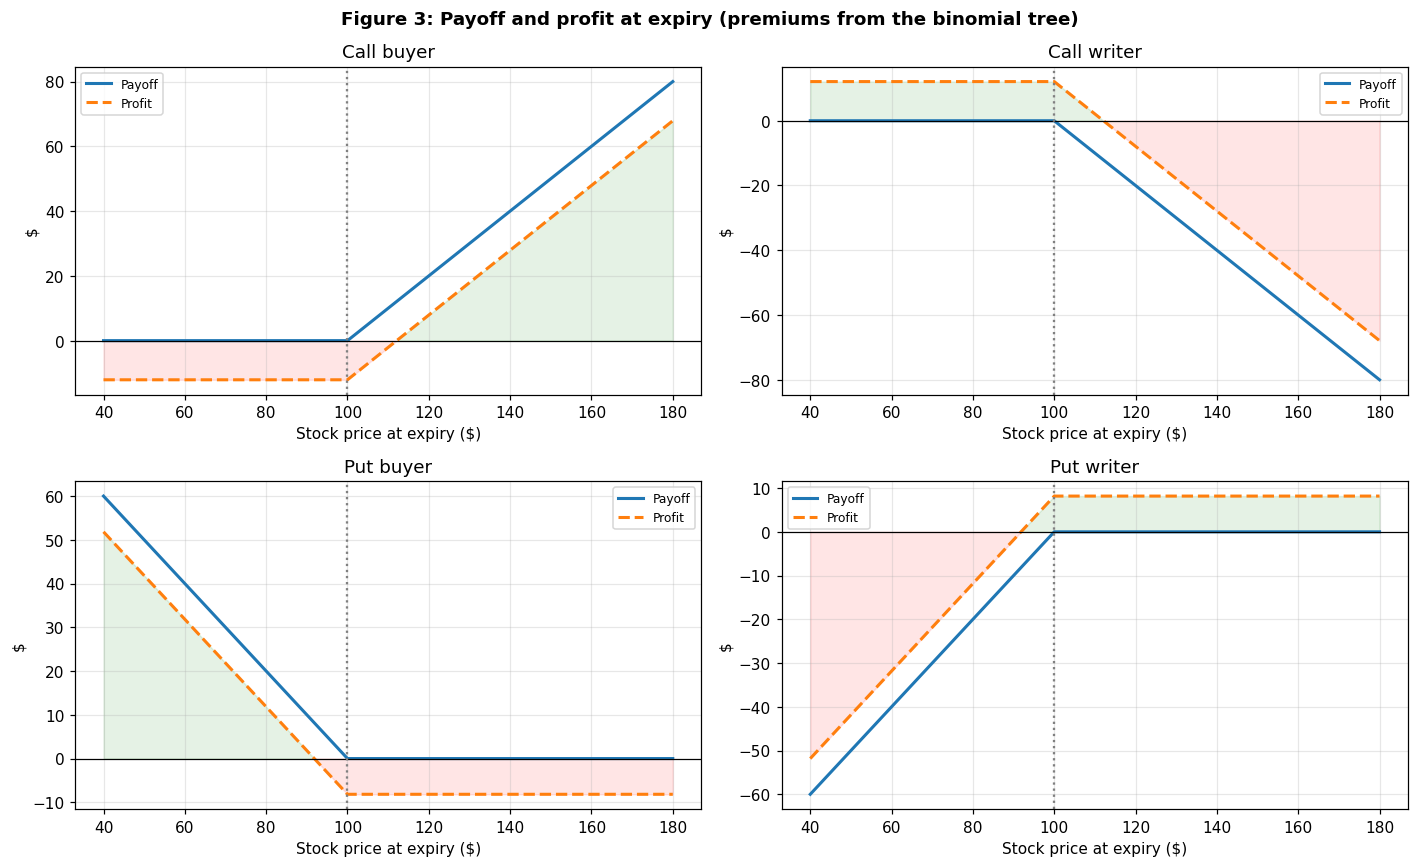

In [6]:
St = np.linspace(40, 180, 400)
positions = [('Call buyer', np.maximum(St - K, 0), call_tree), ('Call writer', -np.maximum(St - K, 0), -call_tree),
             ('Put buyer',  np.maximum(K - St, 0), put_tree),  ('Put writer', -np.maximum(K - St, 0), -put_tree)]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (title, payoff, premium) in zip(axes.flat, positions):
    profit = payoff - premium
    ax.plot(St, payoff, lw=2, label='Payoff'); ax.plot(St, profit, lw=2, ls='--', label='Profit')
    ax.fill_between(St, profit, 0, where=profit > 0, color='green', alpha=0.1)
    ax.fill_between(St, profit, 0, where=profit < 0, color='red', alpha=0.1)
    ax.axhline(0, color='black', lw=0.8); ax.axvline(K, color='gray', ls=':')
    ax.set(title=title, xlabel='Stock price at expiry ($)', ylabel='$'); ax.legend(fontsize=8)
fig.suptitle('Figure 3: Payoff and profit at expiry (premiums from the binomial tree)', fontweight='bold')
plt.tight_layout(); plt.show()

**Buyers vs writers.** Buyers pay the premium and have limited loss with large upside; writers collect the premium and carry the tail risk. A call writer's loss is unlimited as the price rises, and a put writer's loss grows toward $K$ minus the premium as the price falls to zero. Each writer's profit is the mirror image of the buyer's.

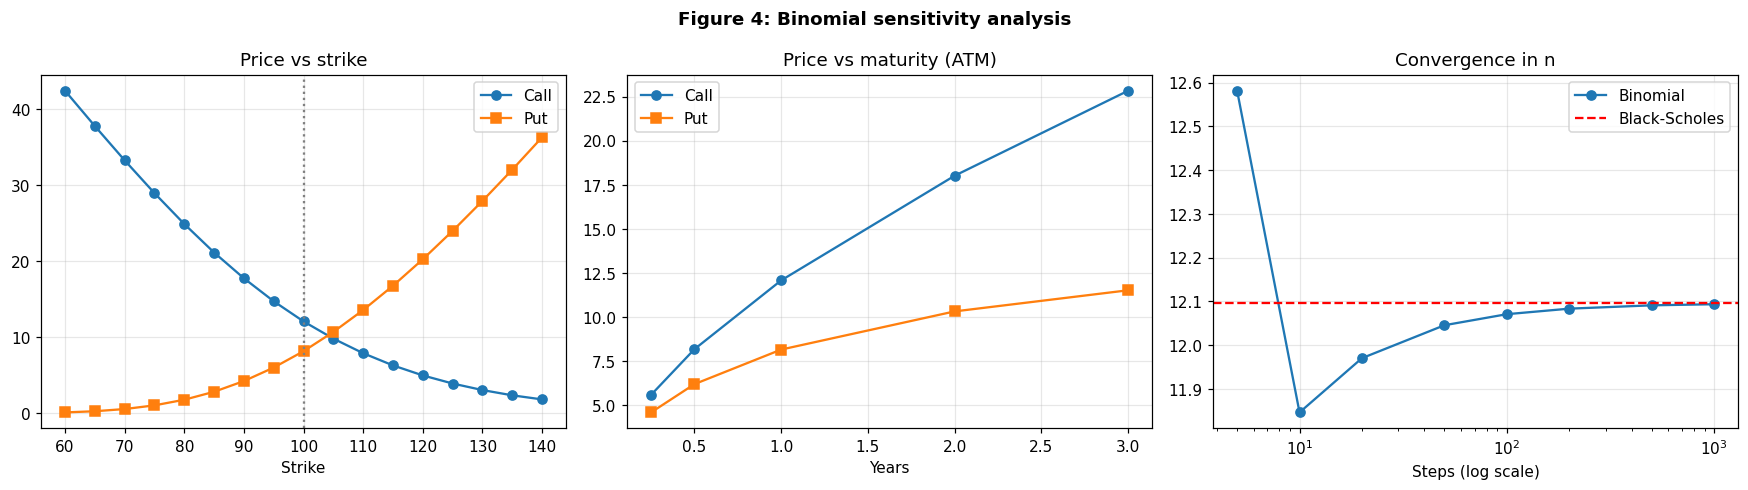

Table 3: Convergence of the binomial call to Black-Scholes


,Steps n,Call,Error vs B-S
0,5,12.5814,0.4852
1,10,11.8465,-0.2497
2,20,11.9704,-0.1258
3,50,12.0457,-0.0505
4,100,12.0709,-0.0253
5,200,12.0835,-0.0127
6,500,12.0911,-0.0051
7,1000,12.0937,-0.0025


In [7]:
# sensitivity 1: strike (moneyness)
strikes = np.arange(60, 145, 5)
sens_K = pd.DataFrame({'Strike': strikes,
                       'Call': [crr_price(S, k, T, R, sigma, N_TREE, 'call') for k in strikes],
                       'Put':  [crr_price(S, k, T, R, sigma, N_TREE, 'put')  for k in strikes]})
# sensitivity 2: maturity
maturities = [0.25, 0.5, 1.0, 2.0, 3.0]
sens_T = pd.DataFrame({'Maturity (yrs)': maturities,
                       'Call': [crr_price(S, K, t, R, sigma, N_TREE, 'call') for t in maturities],
                       'Put':  [crr_price(S, K, t, R, sigma, N_TREE, 'put')  for t in maturities]})
# sensitivity 3: number of steps
steps = [5, 10, 20, 50, 100, 200, 500, 1000]
bs_ref = bs_price(S, K, T, R, sigma)
sens_n = pd.DataFrame({'Steps n': steps, 'Call': [crr_price(S, K, T, R, sigma, n) for n in steps]})
sens_n['Error vs B-S'] = sens_n['Call'] - bs_ref

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(sens_K['Strike'], sens_K['Call'], marker='o', label='Call'); axes[0].plot(sens_K['Strike'], sens_K['Put'], marker='s', label='Put')
axes[0].axvline(S, color='gray', ls=':'); axes[0].set(title='Price vs strike', xlabel='Strike'); axes[0].legend()
axes[1].plot(sens_T['Maturity (yrs)'], sens_T['Call'], marker='o', label='Call'); axes[1].plot(sens_T['Maturity (yrs)'], sens_T['Put'], marker='s', label='Put')
axes[1].set(title='Price vs maturity (ATM)', xlabel='Years'); axes[1].legend()
axes[2].semilogx(sens_n['Steps n'], sens_n['Call'], marker='o', label='Binomial'); axes[2].axhline(bs_ref, color='red', ls='--', label='Black-Scholes')
axes[2].set(title='Convergence in n', xlabel='Steps (log scale)'); axes[2].legend()
fig.suptitle('Figure 4: Binomial sensitivity analysis', fontweight='bold'); plt.tight_layout(); plt.show()

print('Table 3: Convergence of the binomial call to Black-Scholes')
display(sens_n.round(4))

**Interpretation.** Calls lose value and puts gain value as the strike rises. Both are worth more at longer maturities, because more time means a wider distribution of outcomes; the put rises more slowly because a higher discount on the strike partly offsets it. The binomial price converges to Black-Scholes as $n$ grows, with an error that shrinks roughly like $1/n$ and oscillates between even and odd step counts, because the strike falls at different positions relative to the tree's terminal nodes.

## 5. Monte Carlo under risk-neutral GBM

For pricing, the drift is the risk-free rate $r$, not the estimated $\mu$: under the risk-neutral measure every asset earns $r$ in expectation. Because the terminal price under GBM has a closed form, one normal draw per path is enough. Each estimate is reported with its standard error; the Black-Scholes price should fall inside the 95% confidence interval about 95% of the time.

In [8]:
def mc_call(S, K, T, r, sigma, n_paths, rng, antithetic=False):
    Z = rng.standard_normal(n_paths // 2 if antithetic else n_paths)
    if antithetic:
        Z = np.concatenate([Z, -Z])
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    pay = np.exp(-r * T) * np.maximum(ST - K, 0)
    if antithetic:   # average each pair before computing the standard error
        pay = 0.5 * (pay[:n_paths // 2] + pay[n_paths // 2:])
    return pay.mean(), pay.std(ddof=1) / np.sqrt(len(pay))

rng = np.random.default_rng(SEED)
rows = []
for n in [1_000, 10_000, 100_000, 1_000_000]:
    for anti in [False, True]:
        price, se = mc_call(S, K, T, R, sigma, n, rng, anti)
        rows.append({'Paths': n, 'Antithetic': anti, 'Price': price, 'Std error': se,
                     '95% CI low': price - 1.96*se, '95% CI high': price + 1.96*se,
                     'B-S inside CI': abs(price - bs_ref) < 1.96*se})
mc_table = pd.DataFrame(rows)
print(f'Black-Scholes reference: ${bs_ref:.4f}')
print('Table 4: Monte Carlo call prices')
display(mc_table.round(4))

Black-Scholes reference: $12.0962
Table 4: Monte Carlo call prices


,Paths,Antithetic,Price,Std error,95% CI low,95% CI high,B-S inside CI
0,1000,False,12.7724,0.6216,11.5540,13.9907,True
1,1000,True,11.6568,0.4424,10.7896,12.5239,True
2,10000,False,12.1926,0.1859,11.8282,12.5569,True
3,10000,True,12.1389,0.1405,11.8635,12.4143,True
4,100000,False,12.0527,0.0590,11.9371,12.1684,True
5,100000,True,12.1360,0.0457,12.0465,12.2255,True
6,1000000,False,12.0961,0.0188,12.0593,12.1329,True
7,1000000,True,12.0965,0.0143,12.0685,12.1246,True


**Interpretation.** The standard error falls by about $\sqrt{10} \approx 3.2\times$ for every tenfold increase in paths, the usual $1/\sqrt{N}$ rate. Antithetic variates (pairing each draw $Z$ with $-Z$) reduce the standard error further at no extra cost, because the paired payoffs are negatively correlated. Differences from Black-Scholes are sampling noise, not bias.

## 6. Heston stochastic volatility

$$dS_t = rS_t\,dt + \sqrt{v_t}\,S_t\,dW^S_t, \qquad dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW^v_t, \qquad dW^S dW^v = \rho\,dt$$

Variance mean-reverts to $\theta$ at speed $\kappa$, with volatility of variance $\xi$, and $\rho < 0$ captures the leverage effect (prices fall as volatility rises).

The Heston call is priced two independent ways: **semi-analytically**, by integrating the characteristic function (using the numerically stable "little Heston trap" form of Albrecher et al., 2007), and by **Monte Carlo** with full truncation of negative variance. Agreement between them validates both.

**Parameters.** $v_0 = \theta = \sigma^2$, so average variance matches the historical estimate and differences from Black-Scholes come from the *dynamics* of volatility, not its level. $\kappa = 2$ (a half-life of about 4 months), $\xi = 0.5$ and $\rho = -0.7$ are typical of equity-index calibrations. The Feller condition $2\kappa\theta > \xi^2$ is reported, since variance can touch zero when it fails.

In [9]:
V0, THETA, KAPPA, XI, RHO = sigma**2, sigma**2, 2.0, 0.5, -0.7
print(f'v0 = theta = {V0:.4f}  (vol {sigma:.2%}),  kappa = {KAPPA},  xi = {XI},  rho = {RHO}')
print(f'Feller condition 2*kappa*theta > xi^2: {2*KAPPA*THETA:.4f} > {XI**2:.4f} -> {2*KAPPA*THETA > XI**2}')

def heston_cf(u, S, T, r, v0, kappa, theta, xi, rho):
    # characteristic function of ln(S_T), 'little Heston trap' formulation
    iu = 1j * u
    d = np.sqrt((rho * xi * iu - kappa)**2 + xi**2 * (iu + u**2))
    g = (kappa - rho * xi * iu - d) / (kappa - rho * xi * iu + d)
    e = np.exp(-d * T)
    C = (kappa * theta / xi**2) * ((kappa - rho * xi * iu - d) * T - 2 * np.log((1 - g * e) / (1 - g)))
    D = (v0 / xi**2) * (kappa - rho * xi * iu - d) * (1 - e) / (1 - g * e)
    return np.exp(iu * (np.log(S) + r * T) + C + D)

def heston_call(S, K, T, r, v0, kappa, theta, xi, rho):
    args = (S, T, r, v0, kappa, theta, xi, rho)
    lnK = np.log(K)
    fwd = heston_cf(-1j, *args)   # equals S e^{rT}
    P1 = 0.5 + quad(lambda u: (np.exp(-1j*u*lnK) * heston_cf(u - 1j, *args) / (1j*u*fwd)).real, 1e-8, 200, limit=500)[0] / np.pi
    P2 = 0.5 + quad(lambda u: (np.exp(-1j*u*lnK) * heston_cf(u, *args) / (1j*u)).real, 1e-8, 200, limit=500)[0] / np.pi
    return S * P1 - K * np.exp(-r * T) * P2

def heston_mc(S, K, T, r, v0, kappa, theta, xi, rho, n_paths, n_steps, seed):
    rng = np.random.default_rng(seed)   # fixed seed => common random numbers across parameter values
    dt = T / n_steps
    lnS, v = np.full(n_paths, np.log(S)), np.full(n_paths, v0)
    for _ in range(n_steps):
        z1 = rng.standard_normal(n_paths)
        z2 = rho * z1 + np.sqrt(1 - rho**2) * rng.standard_normal(n_paths)
        vp = np.maximum(v, 0.0)                      # full truncation
        lnS += (r - 0.5 * vp) * dt + np.sqrt(vp * dt) * z1
        v   += kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * z2
    pay = np.exp(-r * T) * np.maximum(np.exp(lnS) - K, 0)
    return pay.mean(), pay.std(ddof=1) / np.sqrt(n_paths)

# sanity check: with almost no vol-of-vol, Heston must collapse to Black-Scholes
print(f'\nCheck (xi -> 0): Heston {heston_call(S, K, T, R, V0, KAPPA, THETA, 1e-4, 0.0):.4f} vs B-S {bs_ref:.4f}')

call_heston = heston_call(S, K, T, R, V0, KAPPA, THETA, XI, RHO)
call_heston_mc, se_heston_mc = heston_mc(S, K, T, R, V0, KAPPA, THETA, XI, RHO, 100_000, 252, SEED)
print(f'Heston semi-analytic: ${call_heston:.4f}')
print(f'Heston Monte Carlo  : ${call_heston_mc:.4f}  (SE {se_heston_mc:.4f}, gap {call_heston_mc - call_heston:+.4f})')

v0 = theta = 0.0659  (vol 25.68%),  kappa = 2.0,  xi = 0.5,  rho = -0.7
Feller condition 2*kappa*theta > xi^2: 0.2637 > 0.2500 -> True

Check (xi -> 0): Heston 12.0962 vs B-S 12.0962
Heston semi-analytic: $11.6785
Heston Monte Carlo  : $11.7215  (SE 0.0458, gap +0.0430)


### Sensitivity to ρ and ξ, and the implied-volatility skew

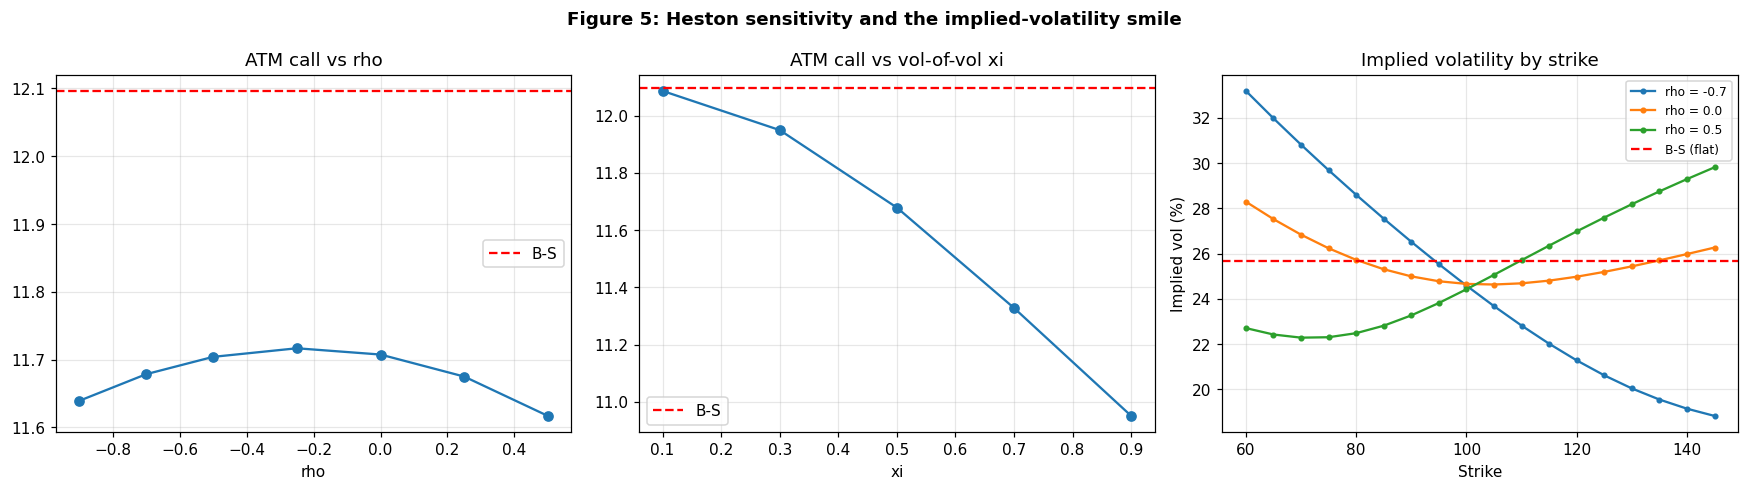

,rho,Call
0,-0.90,11.6392
1,-0.70,11.6785
2,-0.50,11.7040
3,-0.25,11.7167
4,0.00,11.7074
5,0.25,11.6749
6,0.50,11.6169


,xi,Call
0,0.1,12.0864
1,0.3,11.9494
2,0.5,11.6785
3,0.7,11.3275
4,0.9,10.9503


In [10]:
rhos = [-0.9, -0.7, -0.5, -0.25, 0.0, 0.25, 0.5]
xis  = [0.1, 0.3, 0.5, 0.7, 0.9]
sens_rho = pd.DataFrame({'rho': rhos, 'Call': [heston_call(S, K, T, R, V0, KAPPA, THETA, XI, r_) for r_ in rhos]})
sens_xi  = pd.DataFrame({'xi': xis,  'Call': [heston_call(S, K, T, R, V0, KAPPA, THETA, x_, RHO) for x_ in xis]})

def implied_vol(price, S, K, T, r):
    return brentq(lambda s: bs_price(S, K, T, r, s) - price, 1e-4, 5.0)

smile_K = np.arange(60, 150, 5)
smile = pd.DataFrame({'Strike': smile_K})
for r_ in [-0.7, 0.0, 0.5]:
    smile[f'rho = {r_}'] = [implied_vol(heston_call(S, k, T, R, V0, KAPPA, THETA, XI, r_), S, k, T, R) for k in smile_K]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(sens_rho['rho'], sens_rho['Call'], marker='o'); axes[0].axhline(bs_ref, color='red', ls='--', label='B-S')
axes[0].set(title='ATM call vs rho', xlabel='rho'); axes[0].legend()
axes[1].plot(sens_xi['xi'], sens_xi['Call'], marker='o'); axes[1].axhline(bs_ref, color='red', ls='--', label='B-S')
axes[1].set(title='ATM call vs vol-of-vol xi', xlabel='xi'); axes[1].legend()
for col in smile.columns[1:]:
    axes[2].plot(smile['Strike'], smile[col] * 100, marker='.', label=col)
axes[2].axhline(sigma * 100, color='red', ls='--', label='B-S (flat)')
axes[2].set(title='Implied volatility by strike', xlabel='Strike', ylabel='Implied vol (%)'); axes[2].legend(fontsize=8)
fig.suptitle('Figure 5: Heston sensitivity and the implied-volatility smile', fontweight='bold'); plt.tight_layout(); plt.show()

display(sens_rho.round(4)); display(sens_xi.round(4))

**Interpretation.** Because these prices come from the semi-analytic formula, the curves are smooth and free of simulation noise, so the effects are real.

- **ρ:** negative correlation fattens the left tail and thins the right tail of the return distribution. The at-the-money call changes only modestly, but the effect is large away from the money, as the implied-volatility plot shows.
- **ξ:** more vol-of-vol makes the distribution more peaked with fatter tails, which lowers the at-the-money price relative to Black-Scholes while raising far out-of-the-money prices.
- **The skew:** with ρ < 0, Heston produces the downward-sloping implied volatility seen in equity markets (low strikes have higher implied vol); ρ = 0 gives a symmetric smile, and ρ > 0 tilts it the other way. Black-Scholes implies a flat line at σ.

## 7. Summary: the same call priced five ways

In [11]:
mc_1m = mc_table[(mc_table['Paths'] == 1_000_000) & mc_table['Antithetic']].iloc[0]
summary = pd.DataFrame([
    {'Method': f'Binomial (CRR, n={N_TREE})', 'Call price': call_tree, 'Check': f'{call_tree - bs_ref:+.4f} vs B-S'},
    {'Method': 'Black-Scholes', 'Call price': bs_ref, 'Check': 'closed form'},
    {'Method': 'Monte Carlo GBM (1M paths, antithetic)', 'Call price': mc_1m['Price'], 'Check': f"SE {mc_1m['Std error']:.4f}"},
    {'Method': 'Heston semi-analytic', 'Call price': call_heston, 'Check': 'collapses to B-S as xi -> 0'},
    {'Method': 'Heston Monte Carlo (100k paths)', 'Call price': call_heston_mc, 'Check': f'SE {se_heston_mc:.4f}'},
]).set_index('Method')
print(f'{TICKER}-calibrated at-the-money call: S0 = K = 100, T = 1 year, r = {R:.1%}, sigma = {sigma:.2%}')
display(summary.round(4))

MSFT-calibrated at-the-money call: S0 = K = 100, T = 1 year, r = 4.0%, sigma = 25.68%


,Call price,Check
Method,,
"Binomial (CRR, n=500)",12.0911,-0.0051 vs B-S
Black-Scholes,12.0962,closed form
"Monte Carlo GBM (1M paths, antithetic)",12.0965,SE 0.0143
Heston semi-analytic,11.6785,collapses to B-S as xi -> 0
Heston Monte Carlo (100k paths),11.7215,SE 0.0458


## 8. Conclusions and limitations

- The binomial tree, Black-Scholes and GBM Monte Carlo agree, because all three assume the same lognormal model; their differences are discretization or sampling error, and both shrink predictably.
- Heston differs from Black-Scholes even with the same average variance, because stochastic, correlated volatility changes the *shape* of the return distribution. That shape difference is what generates the volatility skew observed in real option markets, which Black-Scholes cannot produce.
- **Practical difficulty of Heston:** its five parameters must be calibrated jointly to market option prices across strikes and maturities. The problem is non-convex, parameters trade off against each other (e.g. κ and θ), and estimates can shift noticeably from day to day.
- **Limitations of this notebook:** Heston parameters here are illustrative rather than calibrated to market prices; volatility comes from historical returns, not implied volatility; European options only; no dividends, jumps or transaction costs.
- **Natural extensions:** calibrate Heston to a real option chain, add American options (early exercise in the tree), and add a jump component (Bates model).